# TRABAJO Parte 2: AIA_2025-2026

# Nombre y DNI del alumno/a 1: PABLO MORÓN GARCÍA - 53962040S
# Nombre y DNI del alumno/a 2: JUAN MANUEL VARGAS BELLIDO - 32902126M

# Transfer Learning con CNNs - Dataset: Flowers

La idea de este trabajo es familiarizarnos con dos situaciones muy habituales en la actividad real de un "Machine Learning Engineer":

1.   En primer lugar, con una de las técnicas más potentes asociadas con las redes neuronales: el **Transfer Learning**. Dado que las redes neuronales, para resolver un problema, capturan en su estructura de capas y pesos una representación jerárquica del problema.
Entonces..., ¿por que no aprovechar ese conocimiento obtenido, para resolver otro problema diferente?

2.  En segundo lugar, con la **busqueda de información sobre conceptos nuevos**. En este caso, los dos primeros modelos a implementar los hemos trabajado en clase. No así el Transfer Learning, y por tanto, debereis buscar vosotros mismos como hacer lo que se pide para el Modelo 3. Consultar en blogs, web y tutoriales es algo común en el día a día de alguien que quiere profundizar en el ML y, para ello, existen infinidad de fuentes. A modo de ejemplo, una fuente para profundizar en el Transfer Learning con redes convolucionales es: https://www.learndatasci.com/tutorials/hands-on-transfer-learning-keras/

En este trabajo vamos intentar resolver un problema de clasificación sobre un dataset propuesto por Tensorflow en 2019 conocido como "flowers". Este conjunto está formado por 3670 imágenes de flores pertenecientes a 5 clases diferentes. Para ello implementaremos 3 modelos:

*   Modelo 1: implementación de una CNN básica.
*   Modelo 2: es una evolución del modelo anterior, aplicando técnicas que reduzcan el overfitting.
*   Modelo 3: rompemos la barrera de tener que seguir complicando nuestro modelo y se pide aplicar transfer learning utilizando un pre-trained model.





# a) Carga de datos

In [ ]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import pandas as pd

import pathlib
import os
import glob
import shutil
tf.__version__

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
import warnings
warnings.filterwarnings('ignore')

Descargamos el dataset que pone a nuestra disposición Tensorflow.

In [ ]:
_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

zip_file = tf.keras.utils.get_file(origin=_URL,
                                   fname="flower_photos.tgz",
                                   extract=True,
                                   )

base_dir = os.path.join(os.path.dirname(zip_file), 'flower_photos')

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Tras completar la descarga, debemos tener la siguiente estructura de directorios:  

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>daisy</b>
|__ <b>dandelion</b>
|__ <b>roses</b>
|__ <b>sunflowers</b>
|__ <b>tulips</b>
</pre>

Desgraciadamente, para este dataset, Tensorflow no nos proporciona la estructura de directorios necesaria de train y de validación. Por lo que debemos proceder del siguiente modo:

* Crear una carpeta `train` y de `val`, cada una de ellas debe contener a su vez, cinco subdirectorios: uno para cada clase de flor.
* Moveremos las imágenes de las carpetas originales a estas nuevas carpetas. De modo que el 80% de las imágenes vayan al conjunto de train y el 20% restante al de validación.
* La estructura final de directorios debe ser la siguiente:

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>train</b>
    |______ <b>daisy</b>: [12.jpg, 28.jpg, 31.jpg ....]
    |______ <b>dandelion</b>: [41.jpg, 22.jpg, 35.jpg ....]
    |______ <b>roses</b>: [121.jpg, 92.jpg, 38.jpg ....]
    |______ <b>sunflowers</b>: [93.jpg, 23.jpg, 83.jpg ....]
    |______ <b>tulips</b>: [109.jpg, 267.jpg, 93.jpg ....]
 |__ <b>val</b>
    |______ <b>daisy</b>: [507.jpg, 508.jpg, 509.jpg ....]
    |______ <b>dandelion</b>: [719.jpg, 720.jpg, 721.jpg ....]
    |______ <b>roses</b>: [514.jpg, 515.jpg, 516.jpg ....]
    |______ <b>sunflowers</b>: [560.jpg, 561.jpg, 562.jpg .....]
    |______ <b>tulips</b>: [640.jpg, 641.jpg, 642.jpg ....]
</pre>

Creamos una lista con el nombre de las 5 clases. En castellano sería: margaritas, diente de león, rosas, girasoles y tulipanes.

In [ ]:
classes = ['roses', 'daisy', 'dandelion', 'sunflowers', 'tulips']

Creemos la estructura de directorios necesaria:

In [ ]:
base_dir = os.path.expanduser("~/.keras/datasets/flower_photos_extracted/flower_photos/")

Preparamos variables con las rutas de los diferentes directorios a crear:

In [ ]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

daisy_dir = os.path.join(train_dir, 'daisy')
dandelion_dir = os.path.join(train_dir, 'dandelion')
roses_dir = os.path.join(train_dir, 'roses')
sunflowers_dir = os.path.join(train_dir, 'sunflowers')
tulips_dir = os.path.join(train_dir, 'tulips')

In [ ]:
SPLIT_RATIO=0.8

for cl in classes:
    # path de las imagenes de la clase cl
    img_path = os.path.join(base_dir, cl)

    # obtenemos la lista de todas las imagenes
    images = glob.glob(img_path + '/*.jpg')
    print("{}: {} Imagenes".format(cl, len(images)))

    # determinamos cuantas imagenes son el 80%
    num_train = int(round(len(images)*SPLIT_RATIO))

    # separamos las imagenes en dos listas
    train, val = images[:num_train], images[num_train:]

    # creamos la carpeta de train/clase y val/clase
    if not os.path.exists(os.path.join(base_dir, 'train', cl)):
        os.makedirs(os.path.join(base_dir, 'train', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'train', cl))

    if not os.path.exists(os.path.join(base_dir, 'val', cl)):
        os.makedirs(os.path.join(base_dir, 'val', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'val', cl))

    for t in train:
        shutil.move(t, os.path.join(base_dir, 'train', cl))

    for v in val:
        shutil.move(v, os.path.join(base_dir, 'val', cl))


roses: 641 Imagenes
daisy: 633 Imagenes
dandelion: 898 Imagenes
sunflowers: 699 Imagenes
tulips: 799 Imagenes


**Tarea 1: Muestre el nombre de dos ficheros cualquiera en alguna de esas rutas**

In [ ]:
ruta_ejemplo = os.path.join(train_dir, 'daisy')
ficheros = glob.glob(os.path.join(ruta_ejemplo, '*.jpg'))
print("Ruta:", ruta_ejemplo)
print("Fichero 1:", os.path.basename(ficheros[0]))
print("Fichero 2:", os.path.basename(ficheros[1]))

Ruta: /root/.keras/datasets/flower_photos_extracted/flower_photos/train/daisy
Fichero 1: 9350942387_5b1d043c26_n.jpg
Fichero 1: 8710109684_e2c5ef6aeb_n.jpg


Es decir, la clase a la que pertenece cada imagen no viene dada por el nombre del fichero sino por el directorio en el que se encuentra almacenada.

**Tarea 2: Muestra el número de imágenes de train que tenemos de cada clase**

In [ ]:
for c in classes:
    ruta_clase = os.path.join(train_dir, c)
    num_imagenes = len(glob.glob(os.path.join(ruta_clase, '*.jpg')))
    print(f"{c}: {num_imagenes} imágenes de train")

roses: 513 imágenes de train
daisy: 506 imágenes de train
dandelion: 718 imágenes de train
sunflowers: 559 imágenes de train
tulips: 639 imágenes de train


# b) Visualización del dataset

**Tarea 3: Muestra 3 imágenes de cada una de las clases, el título de la imagen será el shape del array de numpy asociado a la imagen**

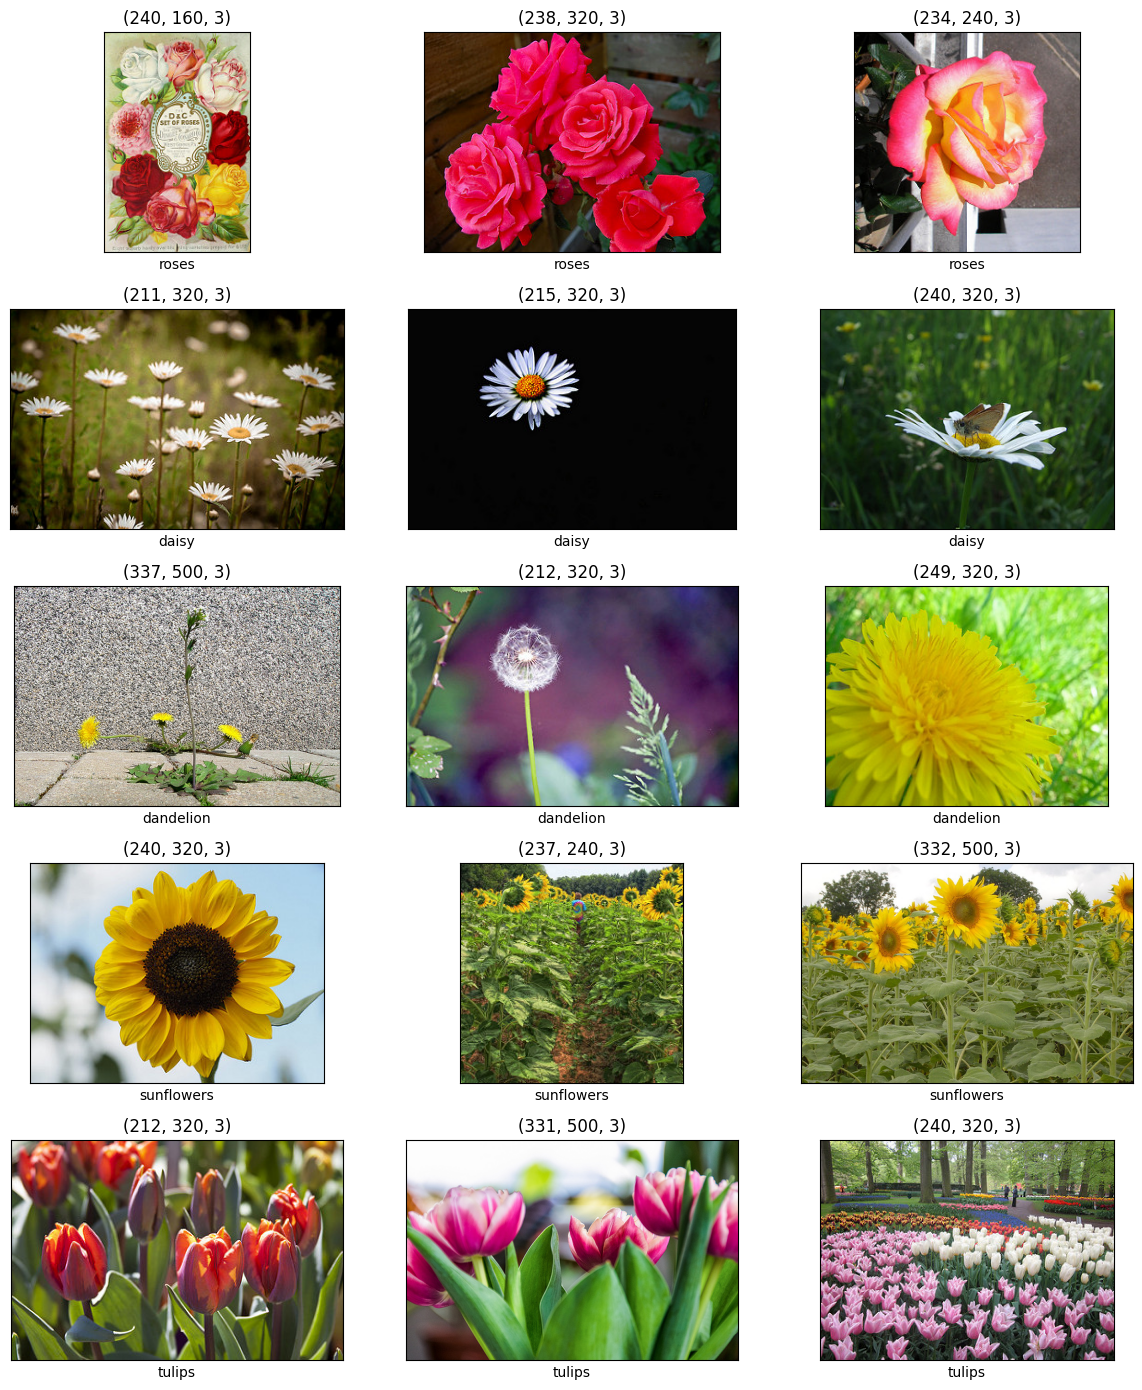

In [ ]:
plt.figure(figsize=(12, 14))
contador = 1

for cl in classes:
    ruta_clase = os.path.join(train_dir, cl)
    imagenes = glob.glob(os.path.join(ruta_clase, '*.jpg'))[:3]

    for ruta in imagenes:
        img = mpimg.imread(ruta)

        plt.subplot(len(classes), 3, contador)
        plt.imshow(img)
        plt.title(str(img.shape))
        plt.xlabel(cl)
        plt.xticks([])
        plt.yticks([])
        contador += 1

plt.tight_layout()


# c) Modelo 1: CNN básica (objetivo: accuracy_valid > 60%)


Implemente una red convolucional para resolver el problema de clasificación. Para ello se sugiere una CNN con 3 capas convolucionales + pooling con la siguiente estructura:

Bloque de procesamiento de imagen:
1.   32 kernels -> 64 kernels -> 96 kernels
2.   kernels de 3x3.
3.   Stride = 1 y padding = SI.
4.   Función de activación ReLU.
5.   Maxpooling de 2x2 con stride clásico de 2 pixeles.
6.   Igualamos el tamaño de todas las imágenes a 150 x 150.

Bloque de decisión:
7.   Capa densa de 512 neuronas.
8.   Capa densa de salida.

**Tarea 4: Define un modelo con la estructura anterior**



In [ ]:
modelo_1 = keras.Sequential(name='modelo_1_cnn_basica')

# Entrada: (150, 150, 3)
modelo_1.add(keras.layers.Conv2D(filters=32,kernel_size=(3, 3),strides=(1, 1),padding='same',activation='relu',input_shape=(150, 150, 3),name='conv_1'))

modelo_1.add(keras.layers.MaxPooling2D(pool_size=(2, 2),strides=(2, 2),name='pool_1'))

modelo_1.add(keras.layers.Conv2D(filters=64,kernel_size=(3, 3),strides=(1, 1),padding='same',activation='relu',name='conv_2'))

modelo_1.add(keras.layers.MaxPooling2D(pool_size=(2, 2),strides=(2, 2),name='pool_2'))

modelo_1.add(keras.layers.Conv2D(filters=96,kernel_size=(3, 3),strides=(1, 1),padding='same',activation='relu',name='conv_3'))
modelo_1.add(keras.layers.MaxPooling2D(pool_size=(2, 2),strides=(2, 2),name='pool_3'))

modelo_1.add(keras.layers.Flatten(name='flatten'))
modelo_1.add(keras.layers.Dense(units=512, activation='relu', name='densa_1'))
modelo_1.add(keras.layers.Dense(units=5, activation='softmax', name='salida'))

**Tarea 5: Indica el shape de la imagen antes y después de cada capa de la red. Explica cómo has obtenido dichos valores**

|Capa| Shape a la salida| #parámetros |
|:-|:-:|:-:|
|Entrada|(150,150,3)|0
|Conv_1|(150,150,32)|896
|Pool_1|(75,75,32)|0
|Conv_2|(75,75,64)|18496
|Pool_2|(37,37,64)|0
|Conv_3|(37,37,96)|55392
|Pool_3|(18,18,96)|0
|flatten|(31104)|0
|densa_1|(512)|15925760
|salida|5|2565

Inicialmente la entrada de la red sería `(150,150,3)`, ya que como dice el eneunciado se igualan los tamaños de las imagenes a (150,150) y 3 canales, ya que la imagen es RGB.

##CAPAS CONVOLUCIONALES

Conv1: Aumentamos la profundidad a 32 pero mantenemos el tamaño ya que al usar padding este no disminuye.

Conv2: Mantendriamos el tamaño de la imagen pero aumentamos la profundidad a 64, como nos indica el problema.

Conv3: Mantendriamos el tamaño de la imagen pero aumentamos la profundidad a 96, como nos indica el problema.

En las capas convolucinales, la forma de calcular los parametros es la misma siempre. Para calcularlo usamos la siguiente operación:

 `(ancho_kernel * alto_kernel * canales_entrada + bias) * numero_filtros`

##CAPAS DE POOLING

En cuanto a las capas de `MaxPooling2D` usamos una ventana `(2 x 2)` con `stride=2`, por lo que aproximadamente se divide entre 2 la altura y la anchura. Si la división es impar nos quedamos con la parte entera solo. En relación a los parametros, en las capas de `pooling` estos siempre serán 0.

##CAPA FLATTEN

La capa `Flatten` no tiene parámetros, solamente convierte el tensor `(18, 18, 96)` en un vector de tamaño:

`18 * 18 * 96 = 31.104`

La primera capa densa tiene:

`(31.104 + 1) * 512 = 15.925.760` parámetros.

Ya por último la salida valdría 5 ya que son el número de clases que tenemos. En cuanto a los parametros de la capa de salida de salida, se calculan con la siguiente fórmula:
  `entrada * neuronas_salida + bias`




**Tarea 6: Compara el resultado con un summary() del modelo**


In [ ]:
modelo_1.summary()

Model: "modelo_1_cnn_basica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 37, 37, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 31104)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_1 (Dense)                 │ (None, 512)            │    15,925,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,003,109 (61.05 MB)

 Trainable params: 16,003,109 (61.05 MB)

 Non-trainable params: 0 (0.00 B)

**Tarea 7: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 60%.**

* Utilice el optimizador que considere más adecuado.
*   Recuerda que si no se realiza conversión a One-Hot de la etiqueta a predecir, debes utilizar como función de error `SparseCategoricalCrossentropy` (este es el procedimiento que hemos usado en clase).
*   Considera un learning rate en el entorno de 0.001.
*   En el caso de los generators utiliza `class_mode='sparse'`.
*   Puedes utilizar p.e. un `batch_size = 100`.

In [ ]:
batch_size = 100
tamaño_modelo_1 = (150, 150)

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=tamaño_modelo_1
,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True,
    seed=123)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=tamaño_modelo_1
,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False)

optim = keras.optimizers.Adam(learning_rate=0.001)

modelo_1.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
                optimizer=optim,
                metrics=['accuracy'])

early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                            patience=5,
                                            restore_best_weights=True)

historial_modelo_1 = modelo_1.fit(
    train_generator,
    epochs=25,
    validation_data=validation_generator,
    callbacks=[early_stopping],
    verbose=2)



**Tarea 8: Muestra la evolución de la función de error (train y valid) durante el entrenamiento.Explica que problema presenta el modelo que hemos entrenado.**

In [ ]:
pd.DataFrame({'loss_train': historial_modelo_1.history['loss'],
              'loss_valid': historial_modelo_1.history['val_loss']}).plot(figsize=(8,4))

plt.grid(True)
plt.xlabel('Número de epochs')
plt.ylabel('Loss')
plt.title('Modelo 1: evolución de la función de error');

pd.DataFrame({'acc_train': historial_modelo_1.history['accuracy'],
              'acc_valid': historial_modelo_1.history['val_accuracy']}).plot(figsize=(8,4))

plt.grid(True)
plt.xlabel('Número de epochs')
plt.ylabel('Accuracy')
plt.title('Modelo 1: evolución del accuracy');

El problema principal del modelo 1 es el **overfitting**. Esto se observa cuando la función de error del entrenamiento baja y la precisión de entrenamiento sube, pero la función de error de validación se estanca o aumenta y la precisión de validación queda claramente por debajo. En ese caso, el modelo está aprendiendo demasiado bien las imágenes de entrenamiento, pero no generaliza igual de bien con imágenes nuevas.

# d) Modelo 2: reducción del overfitting (objetivo: accuracy_valid > 70%)

Para mejorar el accuracy del modelo, vamos a incorporar las dos técnicas más habituales de reducción del overfitting:

    * drop-out
    * data augmentation
    

**Tarea 9: Explica en que consisten y qué utilidad tienen para nuestro problema**





Ambas técnicas son utilizadas para reducir el overtfitting de nuestros modelos:


*   **Drop-out:** Evita que la red dependa demasiado de neuronas concretas, obligandola a aprender representaciones más robustas.
*   **Data Augmentation:** Consiste en crear nuevas imágenes aplicando transformaciones que no cambien la etiqueta real. Esto permite añadir elementos y variedad al dataset mediante la generacion de variantes realistas de las imagenes originales.



**Tarea 10: Construye un nuevo modelo 2 incorporando (en el modelo 1 anterior) el dropout adecuado**

In [ ]:
input = keras.layers.Input(shape=(150, 150, 3), name='input_layer')

x = keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv_1')(input)
x = keras.layers.MaxPooling2D((2, 2), strides=(2, 2), name='pool_1')(x)

x = keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv_2')(x)
x = keras.layers.MaxPooling2D((2, 2), strides=(2, 2), name='pool_2')(x)

x = keras.layers.Conv2D(96, (3, 3), padding='same', activation='relu', name='conv_3')(x)
x = keras.layers.MaxPooling2D((2, 2), strides=(2, 2), name='pool_3')(x)

x = keras.layers.Flatten(name='flatten')(x)
x = keras.layers.Dense(512, activation='relu', name='densa_1')(x)
x = keras.layers.Dropout(0.5, name='dropout_1')(x)

output = keras.layers.Dense(5, activation='softmax', name='salida')(x)

modelo_2 = keras.Model(input, output, name='modelo_2_dropout')

modelo_2.summary()


**Tarea 11: Explica que tipos de augmentation vas a considerar y que utilidad tienen en nuestro problema de clasificacion**

Para este problema usaremos las siguientes transformaciones de **data augmentation**:

* `rotation_range`: permite que el modelo vea flores ligeramente giradas.
* `width_shift_range` y `height_shift_range`: desplazan la imagen horizontal y verticalmente, simulando flores no centradas.
* `shear_range`: aplica pequeñas deformaciones de perspectiva.
* `zoom_range`: simula flores más cercanas o más alejadas.
* `horizontal_flip`: refleja la imagen horizontalmente, algo razonable porque una flor puede aparecer orientada hacia cualquier lado.

No aplicamos `vertical_flip` porque una flor completamente invertida no suele ser muy natural. Tampoco usaremos transformaciones demasiado agresivas para no generar imágenes poco realistas.


**Tarea 12: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 70%.**

In [ ]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator_aug = train_datagen_aug.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True,
    seed=123)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False)

optim = keras.optimizers.Adam(learning_rate=0.001)

modelo_2.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
                optimizer=optim,
                metrics=['accuracy'])

early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                            patience=7,
                                            restore_best_weights=True)

historial_modelo_2 = modelo_2.fit(
    train_generator_aug,
    epochs=40,
    validation_data=validation_generator,
    callbacks=[early_stopping],
    verbose=2)


**Tarea 13: Muestra la evolucion de la funcion de error durante el entrenamiento. Explica qué diferencias de comportamiento hay entre las gráficas del modelo 1 y el modelo 2**

In [ ]:
pd.DataFrame({'loss_train_modelo_2': historial_modelo_2.history['loss'],
              'loss_valid_modelo_2': historial_modelo_2.history['val_loss']}).plot(figsize=(8,4))

plt.grid(True)
plt.xlabel('Número de épocas')
plt.ylabel('Loss')
plt.title('Modelo 2: evolución de la función de error');

pd.DataFrame({'acc_train_modelo_2': historial_modelo_2.history['accuracy'],
              'acc_valid_modelo_2': historial_modelo_2.history['val_accuracy']}).plot(figsize=(8,4))

plt.grid(True)
plt.xlabel('Número de épocas')
plt.ylabel('Accuracy')
plt.title('Modelo 2: evolución del accuracy');

# Comparación directa de la loss de validación de ambos modelos
pd.DataFrame({'loss_valid_modelo_1': historial_modelo_1.history['val_loss'],
              'loss_valid_modelo_2': historial_modelo_2.history['val_loss']}).plot(figsize=(8,4))

plt.grid(True)
plt.xlabel('Número de épocas')
plt.ylabel('Validation loss')
plt.title('Comparación de loss de validación: Modelo 1 vs Modelo 2');

En comparación con el modelo 1, el modelo 2 debería mostrar menos overfitting porque incorpora **Dropout** y **Data Augmentation**. La diferencia esperada es que la pérdida de validación sea más estable y que la distancia entre entrenamiento y validación sea menor. Aunque el entrenamiento puede ser más lento, el modelo debería generalizar mejor y alcanzar una val_accuracy superior.

# c) Modelo 3: Transfer Learning (objetivo: accuracy_valid > 88%)

En nuestro problema de clasificación de flores, el utilizar CNNs diseñadas y entrenadas por nosotros mismos, aparece una barrera en las proximidades del 75-77% de precisión del modelo (siempre sobre validación).

Para superar este escollo, el siguiente paso natural es la utilización de modelos preentrenados. Existe una gran variedad de ellos basados en redes CNNs clásicas, donde la principal diferencia es que acumulan más capas que nuestros modelos 1 y 2. Adicionalmente, en estos modelos se han ido incorporando diferentes propuestas para mejorar la arquitectura de la CNN.

En general, utilizando estos modelos convolucionales preentrenados podemos alcanzar accuracies próximos al 90%. Normalmente, estos modelos han sido previamente entrenados sobre datasets de gran tamaño y con gran número de categorías. P.e. en subconjuntos de Imagenet (14 millones de imagenes de 22K categorías).

Dado que estos modelos se entrenaron para resolver un problema "relativamente" parecido a nuestro problema de clasificación, parece razonable pensar que podemos aprovechar ese conocimiento capturado en la red para resolver nuestro problema de clasificación de flores.



Para elegir el modelo preentrenado que debe utilizar cada grupo, proceda del siguiente modo:
* Paso 1: sume los DNIs de los componentes del grupo (si el grupo tiene un sólo miembro, vaya directamente al paso 2). res = dni_1 + dn_2
* Paso 2: Aplique la siguiente operación al resultado anterior: res mod 6.
* Paso 3: Tome el modelo cuyo número asociado coincide con el resultado de la operación anterior.
* Paso 4: El porcentaje que aparece entre paréntesis junto al nombre del modelo es el accuracy (en validación) que deberías poder alcanzar sin dificultad utilizando el modelo. En todos los casos considera un input_shape = (224, 224, 3).

  0. Resnet50 (>90%)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/ResNet50

  1. Resnet101 (>90%) input_shape = (224, 224, 3)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet/ResNet101

  2. VGG16 (>90%) input_shape = (224, 224, 3)
  https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/VGG16

  3. VGG19 (>90%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg19/VGG19

  4. Xception (>88%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/xception/Xception

  5. Inceptionv3 (>88%) input_shape = (224, 224, 3) https://www.tensorflow.org/api_docs/python/tf/keras/applications/inception_v3/InceptionV3

P.e. si los DNIs de los alumnos son: 12345678 y 23456781. La suma es 35802459. De donde 35802459 mod 6 = 3. Por tanto, tomaríamos el modelo VGG16.

Recuerda que puedes utilizar el siguiente post como referencia del uso de transfer learning: https://www.learndatasci.com/tutorials/hands-on-transfer-learning-keras/

In [ ]:
dni1 = 32902126
dni2 = 53962040
(dni1+dni2)%6

**Tarea 14: Importa el modelo desde Tensorflow**

Dado que este modelo ha sido entrenado para clasificar entre 1.000 categorías, las capas densas finales del modelo no son útiles para nuestro problema de clasificación de 5 categorías (es lo que suele llamarse include_top = SI/NO). De manera que eliminamos lo que a veces se suele llamar el "top model". De este modo sólo nos quedamos con la parte que hace la funcionalidad de "procesamiento" de la imagen.

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

modelo_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Tarea 15: Personalizar el bloque de decisión**  
Añadimos una capa de flatten y tres nuevas capas densas especificas para nuestro problema con dimensiones 4096, 1072 y la que necesite la capa de salida (con sus correspondientes drop-outs).

In [ ]:
input = keras.layers.Input(shape=(224, 224, 3), name='input')

x = modelo_base(input)
x = keras.layers.Flatten(name='flatten')(x)

x = keras.layers.Dense(4096, activation='relu', name='densa_1')(x)
x = keras.layers.Dropout(0.5, name='dropout_1')(x)

x = keras.layers.Dense(1072, activation='relu', name='densa_2')(x)
x = keras.layers.Dropout(0.5, name='dropout_2')(x)

output = keras.layers.Dense(5, activation='softmax', name='salida')(x)

modelo_3 = keras.Model(input, output, name='modelo_3')

modelo_3.summary()

Model: "modelo_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_1 (Dense)                 │ (None, 4096)           │   411,045,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_2 (Dense)                 │ (None, 1072)           │     4,391,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 5)              │         5,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,030,949 (1.64 GB)

 Trainable params: 438,977,829 (1.64 GB)

 Non-trainable params: 53,120 (207.50 KB)

**Tarea 16: Congelar los pesos que no se vayan a entrenar**

Previo a hacer el denominado `Fine-Tuning` del modelo, indicaremos a Tensorflow que únicamente debe entrenar:

   * Las dos últimas capas convolucionales de la red preentrenada, de las que realizaremos un ajuste fino de los pesos.
   * Las tres capas densas que hemos incluido nuevas.

In [ ]:
# Primero dejamos entrenable el modelo base para poder elegir capas internas concretas.
modelo_base.trainable = True

# Congelamos todas las capas del modelo preentrenado.
for capa in modelo_base.layers:
    capa.trainable = False

# Activamos únicamente las dos últimas capas convolucionales.
capa_conv = [layer for layer in modelo_base.layers
               if isinstance(layer, keras.layers.Conv2D)]

for capa in capa_conv[-2:]:
    capa.trainable = True

print("Capas convolucionales que vamos a ajustar con fine-tuning:")
for capa in capa_conv[-2:]:
    print(capa.name)

print("\nResumen de capas entrenables dentro del modelo preentrenado:")
for capa in modelo_base.layers:
    if capa.trainable:
        print(capa.name, "-> entrenable")

# Las capas densas nuevas quedan entrenables por defecto.
print("\nNúmero total de pesos entrenables del modelo completo:",
      len(modelo_3.trainable_weights))


Capas convolucionales que vamos a ajustar con fine-tuning:
conv5_block3_2_conv
conv5_block3_3_conv

Resumen de capas entrenables dentro del modelo preentrenado:
conv5_block3_2_conv -> entrenable
conv5_block3_3_conv -> entrenable

Número total de pesos entrenables del modelo completo: 10


**Tarea 17: Crear los datagenerators oportunos**

Para ello:
> * Utiliza Data augmentation.  
> * Las imágenes tienen que ser preprocesadas igual que cuando se entrenó el modelo pre.entrenado original. Para ello se utiliza el parámetro `preprocessing_function=preprocess_input` (preprocess_input importado desde `keras.applications.xxxxxx` en ambos generators (train y valid). Por tanto, no hay que indicarle `rescale`. En caso de ser necesario, se encargará `preprocess_input`.  
> * Dado que estamos reutilizando un modelo que no "es nuestro", deberemos ceñirnos al tamaño de imagen que permite la red a la entrada. Recuerda que debe ser: 224x224.

In [ ]:
batch_size_tl = 2
tamaño_imagen_tl = (224, 224)

train_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input)

train_generator_tl = train_datagen_tl.flow_from_directory(
    train_dir,
    target_size=tamaño_imagen_tl,
    batch_size=batch_size_tl,
    class_mode='sparse',
    shuffle=True,
    seed=123)

validation_generator_tl = val_datagen_tl.flow_from_directory(
    val_dir,
    target_size=tamaño_imagen_tl,
    batch_size=batch_size_tl,
    class_mode='sparse',
    shuffle=False)


Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


**Tarea 18: Haz el fine-tuning del modelo con el objetivo de alcanzar un accuracy (sobre el conjunto de validación > 88%).**

A la hora de entrenar un modelo pretrained es típico bajar el learning rate respecto al que utilizaríamos para un modelo nuestro desde cero.

Epoch 1/20
1468/1468 - 183s - 125ms/step - accuracy: 0.6630 - loss: 1.7186 - val_accuracy: 0.8776 - val_loss: 0.5023 - learning_rate: 1.0000e-05
Epoch 2/20
1468/1468 - 135s - 92ms/step - accuracy: 0.8014 - loss: 0.8001 - val_accuracy: 0.8626 - val_loss: 0.5006 - learning_rate: 1.0000e-05
Epoch 3/20
1468/1468 - 138s - 94ms/step - accuracy: 0.8351 - loss: 0.5433 - val_accuracy: 0.9048 - val_loss: 0.2895 - learning_rate: 1.0000e-05
Epoch 4/20
1468/1468 - 137s - 94ms/step - accuracy: 0.8705 - loss: 0.4306 - val_accuracy: 0.9075 - val_loss: 0.3480 - learning_rate: 1.0000e-05
Epoch 5/20
1468/1468 - 137s - 94ms/step - accuracy: 0.8869 - loss: 0.3477 - val_accuracy: 0.9184 - val_loss: 0.2645 - learning_rate: 1.0000e-05
Epoch 6/20
1468/1468 - 136s - 93ms/step - accuracy: 0.9046 - loss: 0.2893 - val_accuracy: 0.9102 - val_loss: 0.2974 - learning_rate: 1.0000e-05
Epoch 7/20

Epoch 7: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
1468/1468 - 137s - 94ms/step - accuracy: 0.922

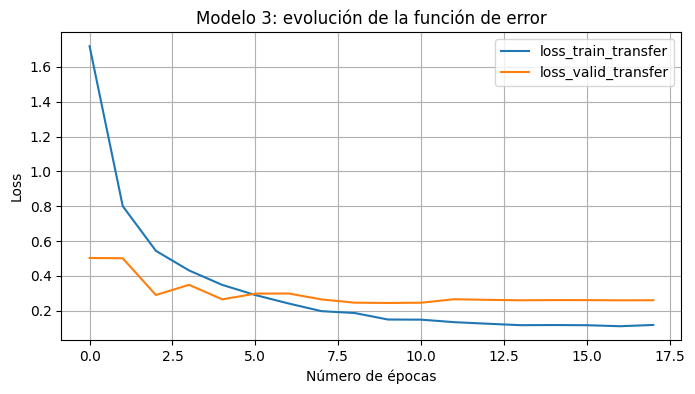

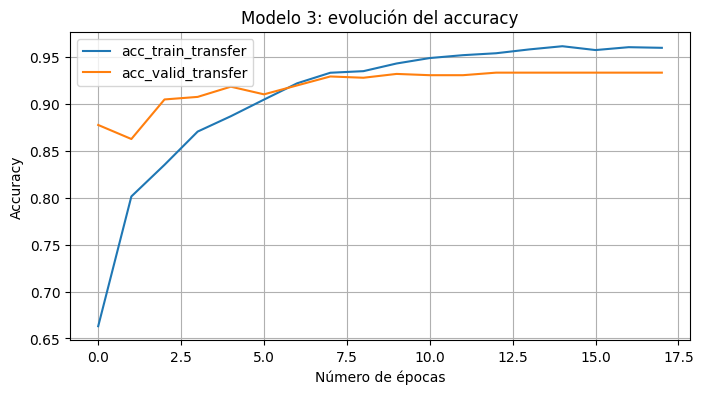

In [ ]:
optim = keras.optimizers.Adam(learning_rate=1e-5)

modelo_3.compile(loss=keras.losses.SparseCategoricalCrossentropy(),
                optimizer=optim,
                metrics=['accuracy'])

early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                            patience=5,
                                            restore_best_weights=True)

reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                              factor=0.2,
                                              patience=2,
                                              min_lr=1e-7,
                                              verbose=1)

historial_modelo_3 = modelo_3.fit(
    train_generator_tl,
    epochs=20,
    validation_data=validation_generator_tl,
    callbacks=[early_stopping, reduce_lr],
    verbose=2)

pd.DataFrame({'loss_train_tl': historial_modelo_3.history['loss'],
              'loss_valid_tl': historial_modelo_3.history['val_loss']}).plot(figsize=(8,4))

plt.grid(True)
plt.xlabel('Número de épocas')
plt.ylabel('Loss')
plt.title('Modelo 3: evolución de la función de error');

pd.DataFrame({'acc_train_tl': historial_modelo_3.history['accuracy'],
              'acc_valid_tl': historial_modelo_3.history['val_accuracy']}).plot(figsize=(8,4))

plt.grid(True)
plt.xlabel('Número de épocas')
plt.ylabel('Accuracy')
plt.title('Modelo 3: evolución del accuracy');

val_loss, val_acc = modelo_3.evaluate(validation_generator_tl, verbose=2)
print("Accuracy en validación del modelo 3:", val_acc)
